# Code for Chapter 2 @ SSTC-NEU modified by Fu
## Build and train a very simple neural network using backpropagation

In [1]:
# %%capture
# !pip install seaborn # Chapter 1已经安装，这里不再安装了
# !pip install lightning

In [2]:
import torch ## torch let's us create tensors and also provides helper functions
import torch.nn as nn ## torch.nn gives us nn.Module(), nn.Embedding() and nn.Linear()
import torch.nn.functional as F # This gives us relu()
from torch.optim import SGD # SGD is short of Stochastic Gradient Descent, but
                            # the way we'll use it, passing in all of the training
                            # data at once instead of passing it random subsets,
                            # it will act just like plain old Gradient Descent.

import lightning as L ## Lightning makes it easier to write, optimize and scale our code
from torch.utils.data import TensorDataset, DataLoader ## We'll store our data in DataLoaders

import matplotlib.pyplot as plt ## matplotlib allows us to draw graphs.
import seaborn as sns ## seaborn makes it easier to draw nice-looking graphs.

In [3]:
## The inputs are the x-axis coordinates for each data point
## These values represent different doses
training_inputs = torch.tensor([0.0, 0.5, 1.0])

## The labels are the y-axis coordinates for each data point
## These values represent the effectiveness
training_labels = torch.tensor([0.0, 1.0, 0.0])

## Now let's package everything up into a DataLoader...
training_dataset = TensorDataset(training_inputs, training_labels)
dataloader = DataLoader(training_dataset)

In [4]:
class myNN(L.LightningModule):

    def __init__(self):

        super().__init__()

        ## Create all of the weights and biases for the network.
        ## However, this time they are initialized with random values.
        ## We are also wrapping the tensors up in nn.Parameter() objects.
        ## PyTorch will only optimize parameters. There are a lot of
        ## different ways to create parameters, and we'll see those
        ## in later examples, but nn.Parameter() is the most basic.
        self.w1 = nn.Parameter(torch.tensor(0.06))
        self.b1 = nn.Parameter(torch.tensor(0.0))

        self.w2 = nn.Parameter(torch.tensor(3.49))
        self.b2 = nn.Parameter(torch.tensor(0.0))

        self.w3 = nn.Parameter(torch.tensor(-4.11))
        self.w4 = nn.Parameter(torch.tensor(2.74))

        self.loss = nn.MSELoss(reduction='sum')


    def forward(self, input_values):
        ## The forward() method is identical to what we used in Chapter 1.

        top_x_axis_values = (input_values * self.w1) + self.b1
        bottom_x_axis_values = (input_values * self.w2) + self.b2

        top_y_axis_values = F.relu(top_x_axis_values)
        bottom_y_axis_values = F.relu(bottom_x_axis_values)

        output_values = (top_y_axis_values * self.w3) + (bottom_y_axis_values * self.w4)

        return output_values
    

    def configure_optimizers(self): # this configures the optimizer we want to use for backpropagation.
        return SGD(self.parameters(), lr=0.01)
        ## NOTE: PyTorch doesn't have a Gradient Descent optimizer, just a
        ## Stochastic Gradient Descent (SGD) optimizer. However, since we
        ## are running all 3 doses through the NN each time, rather than a
        ## random subset, we are essentially doing Gradient Descent instead of
        ## SGD.


    def training_step(self, batch, batch_idx): # take a step during gradient descent.
        ## NOTE: When training_step() is called it calculates the loss with the code below...
        inputs, labels = batch # collect input
        outputs = self.forward(inputs) # run input through the neural network
        loss = self.loss(outputs, labels) ## the `loss` quantifies the difference between
                                          ## the observed drug effectiveness in `labels`
                                          ## and the outputs created by the neural network

        return loss

In [5]:
model = myNN() # First, make model from the class

## Now print out the name and value for each named parameter
## parameter in the model. Remember parameters are variables,
## like Weights and Biases, that we can train.
for name, param in model.named_parameters():
    print(name, torch.round(param.data, decimals=2))

w1 tensor(0.0600)
b1 tensor(0.)
w2 tensor(3.4900)
b2 tensor(0.)
w3 tensor(-4.1100)
w4 tensor(2.7400)


In [6]:
## now run different doses through the neural network.
output_values = model(training_inputs)
torch.round(output_values, decimals=2)

tensor([0.0000, 4.6600, 9.3200], grad_fn=<RoundBackward1>)

In [7]:
## Create the different doses we want to run through the neural network.
## torch.linspace() creates the sequence of numbers between, and including, 0 and 1.
input_doses = torch.linspace(start=0, end=1, steps=11)

# now print out the doses to make sure they are what we expect...
input_doses

tensor([0.0000, 0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000,
        0.9000, 1.0000])

In [8]:
output_values = model(input_doses)
output_values

tensor([0.0000, 0.9316, 1.8632, 2.7948, 3.7264, 4.6580, 5.5896, 6.5212, 7.4528,
        8.3844, 9.3160], grad_fn=<AddBackward0>)

Text(0.5, 0, 'Dose')

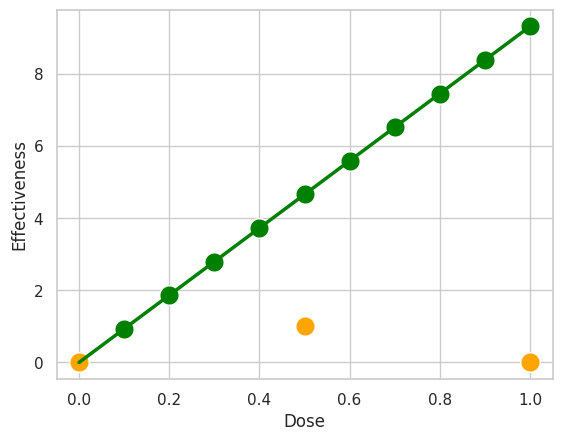

In [9]:
## Now draw a graph that shows how well, or poorly, the model
## predicts the training data. At this point, since the
## model is untrained, there should be a big difference between
## the model's output and the training data.

## First, set the style for seaborn so that the graph looks cool.
sns.set(style="whitegrid")

## First, draw the individual output points
sns.scatterplot(x=input_doses,
                y=output_values.detach().numpy(),
                color='green',
                s=200)

## Now connect those points with a line
sns.lineplot(x=input_doses,
             y=output_values.detach().numpy(), ## NOTE: We call .detatch() because...
             color='green',
             linewidth=2.5)

## Add the values in the training dataset
sns.scatterplot(x=training_inputs,
                y=training_labels,
                color='orange',
                s=200)

## now label the y- and x-axes.
plt.ylabel('Effectiveness')
plt.xlabel('Dose')

In [10]:
model = myNN()
## Now train the model...
trainer = L.Trainer(max_epochs=500, # how many times to go through the training data
                    logger=False,
                    enable_checkpointing=False,
                    enable_progress_bar=False)

trainer.fit(model, train_dataloaders=dataloader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type    | Params | Mode  | FLOPs
---------------------------------------------------------
0 | loss         | MSELoss | 0      | train | 0    
  | other params | n/a     | 6      | n/a   | n/a  
---------------------------------------------------------
6         Trainable params
0         Non-trainable params
6         Total params
0.000     Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode
0         Total Flops
/home/chason/anaconda3/envs/jupyter-server/lib/python3.10/site-packages/lightning/pytorch/utilities/_pytre

In [11]:
## Now that we've trained the model, let's print out the
## new values for each Weight and Bias.
for name, param in model.named_parameters():
    print(name, torch.round(param.data, decimals=3))

w1 tensor(1.4790)
b1 tensor(-0.5680)
w2 tensor(2.6980)
b2 tensor(-0.2580)
w3 tensor(-4.2400)
w4 tensor(1.5840)


In [12]:
## now run the different doses through the neural network.
output_values = model(input_doses)
torch.round(output_values, decimals=2)

tensor([0.0000, 0.0200, 0.4500, 0.8700, 1.2000, 1.0000, 0.8000, 0.6000, 0.4000,
        0.2000, 0.0000], grad_fn=<RoundBackward1>)

Text(0.5, 0, 'Dose')

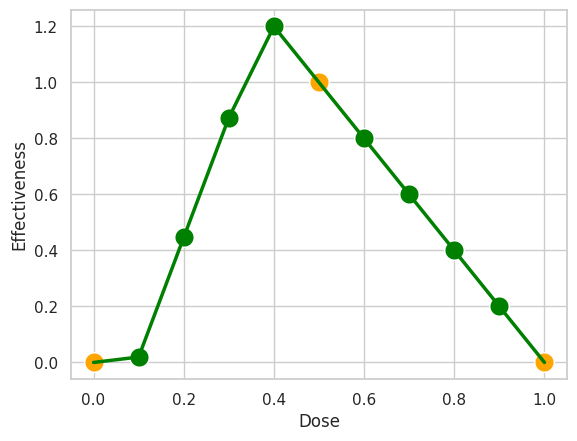

In [13]:
## Now draw a graph that shows how well, or poorly, the model
## predicts the training data. At this point, since we just
## trained th model, the training data should overlap the
## model's output

## First, set the style for seaborn so that the graph looks cool.
sns.set(style="whitegrid")

## First, draw the individual output points
sns.scatterplot(x=input_doses,
                y=output_values.detach().numpy(),
                color='green',
                s=200)

## Now connect those points with a line
sns.lineplot(x=input_doses,
             y=output_values.detach().numpy(), ## NOTE: We call .detatch() because...
             color='green',
             linewidth=2.5)

## Add the values in the training dataset
sns.scatterplot(x=training_inputs,
                y=training_labels,
                color='orange',
                s=200)

## now label the y- and x-axes.
plt.ylabel('Effectiveness')
plt.xlabel('Dose')